# Final Dataset Wrangling + Visualizations

## Data Import
After cleaning and transforming the raw data with dbt, we can import the data directly from PostgreSQL.

In [99]:
# Package and library imports
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [74]:
# 1. Setup local Postgres connection string
DATABASE_URL = "postgresql://Kabir@localhost:5432/resilience_gap"

# 2. Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)

# 3. Load the mart table straight into a Pandas DataFrame
query = "SELECT * FROM dbt_dev.mart_merge"
ess_survey = pd.read_sql(query, con=engine)

print(f"Data loaded. Shape: {ess_survey.shape}")

Data loaded. Shape: (14329, 38)


## Investigating Data Integrity + Additional Cleaning
Here we can investigate data quality, missingness, survey weighting (in dbt we intentionally implemented Winsorization to avoid super heavily weighted individuals skewing models), and grouped sample sizes. We also generate vectors of associated variables, for exampling collapsing the trust variables into one index, as  they  are highly multicollinear and would otherwise skew our models.

In [ ]:
# Review columns in data
ess_survey.columns


Index(['nuts1_region', 'country_code', 'nuts_region', 'respondent_id',
       'model_analysis_wt', 'nuts1_gdp_euro_2022', 'nuts1_gdp_pct_eu_avg_2022',
       'nuts1_unemployment_rate_pct_2022', 'nuts1_net_migration_2022',
       'nuts1_pop_density_2022', 'nuts1_pop_growth_rate_2022',
       'delta_nuts1_gdp_pct_eu_avg_5yr', 'delta_nuts1_unemployment_rate_5yr',
       'delta_nuts1_net_migration_2yr', 'delta_nuts1_pop_growth_rate_5yr',
       'age', 'gender', 'citizen', 'identify_ethnic_majority',
       'educ_attainment', 'hh_income_comfort', 'unemp_last_5_years',
       'how_religious', 'personal_say_govt', 'eu_role', 'country_attachment',
       'eur_attachment', 'trstprl', 'trstlgl', 'trst_pol_parties', 'ppltrst',
       'immigrants_impact_country', 'govt_role_income_inequality',
       'left_right_alignment', 'sat_life', 'voting_behavior_manifest',
       'intergen_educational_mobility', 'rw_populist_vote'],
      dtype='str')

In [76]:
def calculate_cronbach_alpha(df, items):
    df_items = ess_survey[items].dropna()
    k = len(items)
    item_variances = df_items.var(ddof=1).sum()
    total_variance = df_items.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - (item_variances / total_variance))
    return alpha

# Test the trust variables
trust_vars = ['trstprl', 'trstlgl', 'trst_pol_parties']
trust_alpha = calculate_cronbach_alpha(ess_survey, trust_vars)

print(f"Cronbach's Alpha for Institutional Trust Matrix: {trust_alpha:.3f}")
if trust_alpha >= 0.70:
    print("👉 Decision: Statistically justified to collapse into a composite index.")
else:
    print("👉 Decision: Low reliability. Keep a single proxy variable.")

ess_survey["trust_index"] = ess_survey[trust_vars].mean(axis=1, skipna=True)

Cronbach's Alpha for Institutional Trust Matrix: 0.804
👉 Decision: Statistically justified to collapse into a composite index.


In [ ]:
# Check the statistical distribution of active weights and that Winsorization capped survey weighting at 5
print(ess_survey['model_analysis_wt'].describe())

count    14329.000000
mean         1.742354
std          1.216844
min          0.038882
25%          0.613952
50%          1.705909
75%          2.419199
max          5.000000
Name: model_analysis_wt, dtype: float64


In [ ]:
# 1. Calculate the percentage of missing values per country for every column
missing_report = (
    ess_survey.groupby('country_code')
    .apply(lambda x: (x.isnull().sum() / len(x)) * 100)
    # Drop the grouping column from the axis to avoid redundancy
    .drop(columns=['country_code'], errors='ignore')
)

# 2. Transpose the results so columns are rows, making it incredibly easy to scroll through
missing_report_pivoted = missing_report.T

# 3. Display the full matrix (preventing pandas from clipping rows)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(missing_report_pivoted.round(2))

country_code                          DE     ES     FR     GR     IT     PL  \
nuts1_region                        0.00   0.00   0.00   0.00   0.00   0.00   
nuts_region                         0.00   0.00   0.00   0.00   0.00   0.00   
respondent_id                       0.00   0.00   0.00   0.00   0.00   0.00   
model_analysis_wt                   0.00   0.00   0.00   0.00   0.00   0.00   
nuts1_gdp_euro_2022                 0.00   0.00   0.00   0.00   0.00   0.00   
nuts1_gdp_pct_eu_avg_2022           0.00   0.00   0.00   0.00   0.00   0.00   
nuts1_unemployment_rate_pct_2022    0.00   0.00   0.00   0.00   0.00   0.00   
nuts1_net_migration_2022            0.00   0.00   0.00   0.00   0.00   0.00   
nuts1_pop_density_2022              0.00   0.00   0.00   0.00   0.00   0.00   
nuts1_pop_growth_rate_2022          0.00   0.00   0.00   0.00   0.00   0.00   
delta_nuts1_gdp_pct_eu_avg_5yr      0.00   0.00   0.00   0.00   0.00   0.00   
delta_nuts1_unemployment_rate_5yr   0.00   0.00   0.

Our target variable, rw_populist_vote, jumps out as the only variable with significant missingness. This is to be expected: not all respondents in the survey are eligible to vote, some choose not to vote, some refuse to disclose their vote, some are actual missing data, and so on. We now observe how many valid respondents we have in each NUTS-1 region.

In [19]:
# Group by country and region to get total sample vs valid voter counts
region_counts = (
    ess_survey.groupby(["country_code", "nuts1_region"])
    .agg(
        sample_size=("respondent_id", "count"),
        valid_voters=("rw_populist_vote", "count")  # count() natively ignores NaNs
    )
    .reset_index()
)

# Sort from highest to lowest valid voter count
region_counts_sorted = region_counts.sort_values(
    by="valid_voters", ascending=False
)

region_counts_sorted

,country_code,nuts1_region,sample_size,valid_voters
34,GR,EL3,923,593
36,GR,EL5,795,537
37,GR,EL6,752,498
51,SE,SE2,538,474
8,DE,DEA,615,424
50,SE,SE1,431,385
38,IT,ITC,883,366
41,IT,ITH,495,265
1,DE,DE2,396,258
39,IT,ITF,618,252


## Statistical Tests

In [77]:
import scipy.stats as stats
# =====================================================================
# TASK 1: KRUSKAL-WALLIS TEST (Trust Index Across Countries)
# =====================================================================
print("1. RUNNING KRUSKAL-WALLIS H-TEST FOR TRUST SEGMENTATION")

# Drop missing rows for this specific test
df_kw = ess_survey.dropna(subset=["trust_index", "country_code"])

# Isolate trust arrays for each of your 7 countries dynamically
country_groups = [
    group["trust_index"].values
    for name, group in df_kw.groupby("country_code")
]

# Run the test
kw_stat, kw_p = stats.kruskal(*country_groups)

print(f"Kruskal-Wallis H-Statistic : {kw_stat:.4f}")
print(f"p-value                    : {kw_p:.4e}")

if kw_p < 0.05:
    print(
        "\n✅ VERDICT: Statistically Significant! The distribution of institutional trust\n"
        "   is fundamentally and structurally different across these European countries.\n"
        "   This mathematically validates splitting data into distinct national regimes."
    )
else:
    print(
        "\n❌ VERDICT: Not Significant. Trust distributions are statistically uniform across nations."
    )

1. RUNNING KRUSKAL-WALLIS H-TEST FOR TRUST SEGMENTATION
Kruskal-Wallis H-Statistic : 1517.8236
p-value                    : 0.0000e+00

✅ VERDICT: Statistically Significant! The distribution of institutional trust
   is fundamentally and structurally different across these European countries.
   This mathematically validates splitting data into distinct national regimes.


In [78]:
# =====================================================================
# TASK 2: CHI-SQUARE TEST OF INDEPENDENCE (Country vs. Populist Vote)
# =====================================================================
print("2. RUNNING CHI-SQUARE TEST FOR GEOGRAPHIC VOTING CLUSTERING")
print("-" * 60)

# Clean out target missingness to isolate active voters
df_chi = ess_survey.dropna(subset=["rw_populist_vote", "country_code"])

# Generate the cross-tabulation frequency table (Contingency Table)
contingency_table = pd.crosstab(
    df_chi["country_code"], df_chi["rw_populist_vote"]
)

print("Observed Voting Frequencies per Country:")
print(contingency_table)
print("-" * 40)

# Run the Chi-Square test
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic      : {chi2_stat:.4f}")
print(f"Degrees of Freedom (dof)  : {dof}")
print(f"p-value                   : {chi2_p:.4e}")

if chi2_p < 0.05:
    print(
        "\n✅ VERDICT: Statistically Significant! Right-wing populist voting behavior\n"
        "   is heavily dependent on geography. Choosing a populist vs. mainstream party\n"
        "   is not uniformly distributed across borders. This completely justifies use\n"
        "   of Country Clustered Standard Errors and Fixed Effects!"
    )
else:
    print(
        "\n❌ VERDICT: Not Significant. Populist voting rates are statistically independent of country borders."
    )

2. RUNNING CHI-SQUARE TEST FOR GEOGRAPHIC VOTING CLUSTERING
------------------------------------------------------------
Observed Voting Frequencies per Country:
rw_populist_vote   0.0  1.0
country_code               
DE                1545   88
ES                 973   74
FR                 650  175
GR                1712  122
IT                 795  446
PL                 600  439
SE                 970  108
----------------------------------------
Chi-Square Statistic      : 1217.8974
Degrees of Freedom (dof)  : 6
p-value                   : 6.4048e-260

✅ VERDICT: Statistically Significant! Right-wing populist voting behavior
   is heavily dependent on geography. Choosing a populist vs. mainstream party
   is not uniformly distributed across borders. This completely justifies use
   of Country Clustered Standard Errors and Fixed Effects!


## Preliminary Visualizations

In [20]:
# Set theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 13,
    'legend.title_fontsize': 11
})

/var/folders/8x/_6srvv510170nx5xz7b75jp00000gn/T/ipykernel_46924/3361411462.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


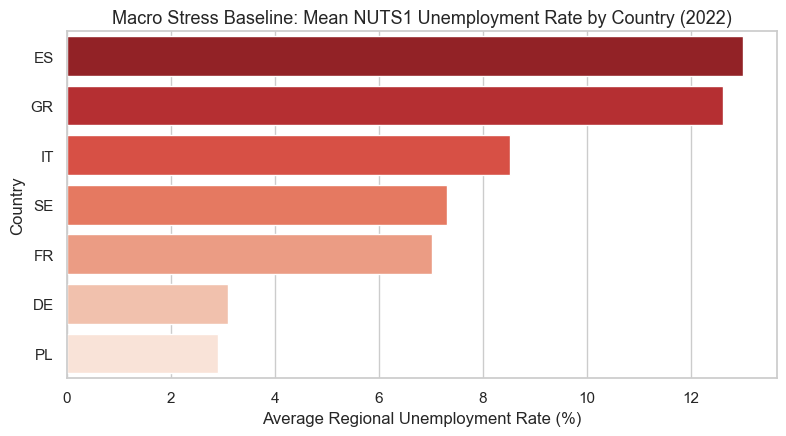

In [21]:
# Unemployment
fig, ax = plt.subplots(figsize=(8, 4.5))

unemp_by_country = (
    ess_survey.groupby('country_code')['nuts1_unemployment_rate_pct_2022']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=unemp_by_country, 
    x='nuts1_unemployment_rate_pct_2022', 
    y='country_code', 
    palette='Reds_r',
    ax=ax
)
ax.set_title('Macro Stress Baseline: Mean NUTS1 Unemployment Rate by Country (2022)')
ax.set_xlabel('Average Regional Unemployment Rate (%)')
ax.set_ylabel('Country')
plt.tight_layout()
#plt.savefig('01_macro_unemployment_by_country.png', dpi=300)



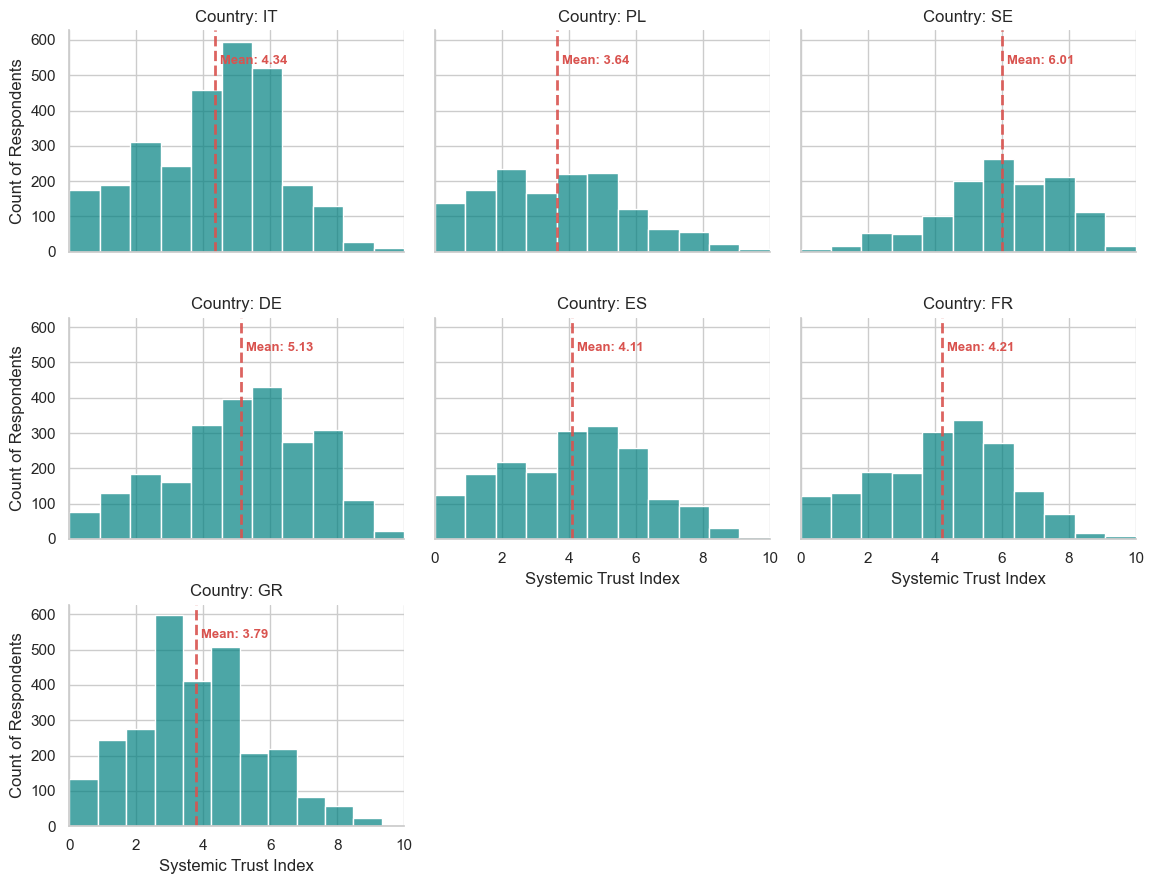

In [79]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

# 4. Define a custom function to calculate and draw the mean line per facet
def draw_mean_line(data, **kwargs):
    mean_val = data['trust_index'].mean()
    ax = plt.gca()
    
    # Draw the dashed vertical line
    ax.axvline(mean_val, color='#d9534f', linestyle='--', linewidth=2, alpha=0.9)
    
    # Annotate the numerical mean value
    # ax.get_xaxis_transform() locks the Y coordinate to a relative scale (0 = bottom, 1 = top)
    # This ensures the text always sits perfectly at 85% height regardless of respondent counts
    ax.text(
        x=mean_val + 0.15, 
        y=0.85, 
        s=f'Mean: {mean_val:.2f}', 
        transform=ax.get_xaxis_transform(), 
        color='#d9534f', 
        weight='bold', 
        fontsize=9.5
    )

# 5. Initialize the FacetGrid (This will dynamically accommodate your 7 countries)
g = sns.FacetGrid(
    ess_survey, 
    col="country_code", 
    col_wrap=3, 
    height=3, 
    aspect=1.3
)

# 6. Map the baseline histograms onto the grid
g.map_dataframe(
    sns.histplot, 
    x="trust_index", 
    bins=11, 
    color="teal", 
    alpha=0.7
)

# 7. Map our custom mean-line function on top of the histograms
g.map_dataframe(draw_mean_line)

# 8. Polish layout and axes boundaries
g.set_axis_labels("Systemic Trust Index", "Count of Respondents")
g.set_titles(col_template="Country: {col_name}")

for ax in g.axes.flat:
    ax.set_xlim(0, 10)
    ax.set_xticks([0, 2, 4, 6, 8, 10])

plt.tight_layout()
#plt.savefig('02_systemic_trust_index_faceted_with_mean.png', dpi=300)

/var/folders/8x/_6srvv510170nx5xz7b75jp00000gn/T/ipykernel_46924/967284003.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


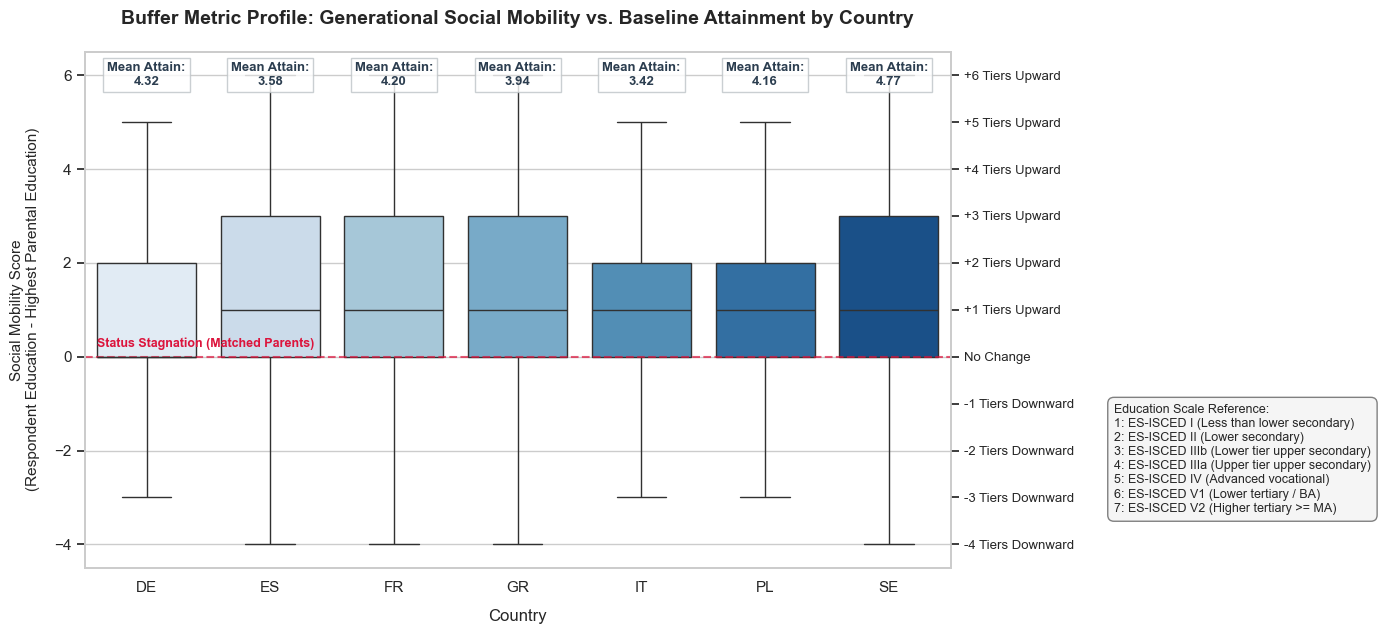

In [28]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

# 1. Define the education level codebook for visual context
education_codebook = {
    1: "ES-ISCED I (Less than lower secondary)",
    2: "ES-ISCED II (Lower secondary)",
    3: "ES-ISCED IIIb (Lower tier upper secondary)",
    4: "ES-ISCED IIIa (Upper tier upper secondary)",
    5: "ES-ISCED IV (Advanced vocational)",
    6: "ES-ISCED V1 (Lower tertiary / BA)",
    7: "ES-ISCED V2 (Higher tertiary >= MA)",
}

# 2. Sort countries sequentially by median mobility score
country_mobility_order = (
    ess_survey.groupby("country_code")["intergen_educational_mobility"]
    .median()
    .sort_values()
    .index
)

# 3. Compute the baseline MEAN educational attainment per country
# We use 'educ_attainment' (the respondent's clean, non-zero education column)
country_mean_attainment = (
    ess_survey.groupby("country_code")["educ_attainment"].mean().to_dict()
)

# 4. Render the clean boxplot
fig, ax1 = plt.subplots(figsize=(11, 6.5))  # Adjusted height slightly for annotations

sns.boxplot(
    data=ess_survey,
    x="country_code",
    y="intergen_educational_mobility",
    order=country_mobility_order,
    palette="Blues",
    ax=ax1,
    showfliers=False,
)

# 5. Format the primary Y-axis (The Relative Scale)
ax1.set_title(
    "Buffer Metric Profile: Generational Social Mobility vs. Baseline Attainment by Country",
    fontsize=14,
    pad=20,
    weight="bold",
)
ax1.set_xlabel("Country", fontsize=12, labelpad=10)
ax1.set_ylabel(
    "Social Mobility Score\n(Respondent Education - Highest Parental Education)",
    fontsize=11,
    labelpad=10,
)

# Add a prominent horizontal baseline at 0 to explicitly divide Upward vs Downward
ax1.axhline(0, color="crimson", linestyle="--", linewidth=1.5, alpha=0.7)
ax1.text(
    -0.4,
    0.2,
    "Status Stagnation (Matched Parents)",
    color="crimson",
    fontsize=9,
    weight="bold",
)

# 6. Dynamically add the Mean Baseline Attainment labels at the top of the chart
# We find the top of the current Y-axis limit to place the labels uniformly
top_y_limit = ax1.get_ylim()[1]
annotation_y_position = top_y_limit - 0.5  # Position slightly below the very top edge

for i, country in enumerate(country_mobility_order):
    mean_val = country_mean_attainment.get(country, np.nan)
    if not pd.isna(mean_val):
        ax1.text(
            i,
            annotation_y_position,
            f"Mean Attain:\n{mean_val:.2f}",
            ha="center",
            va="center",
            fontsize=9.5,
            weight="bold",
            color="#2c3e50",
            bbox=dict(
                boxstyle="square,pad=0.3",
                facecolor="white",
                edgecolor="#bdc3c7",
                alpha=0.8,
            ),
        )

# 7. Create a secondary Y-axis to map the magnitude of the shifts to the codebook
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())  # Keep scales perfectly aligned

# Generate tick marks showing the step distance
ticks = np.arange(int(ax1.get_ylim()[0]), int(ax1.get_ylim()[1]) + 1)
ax2.set_yticks(ticks)

# Format the labels dynamically to show what a change of +2 or -1 actually means
labels = []
for t in ticks:
    if t > 0:
        labels.append(f"+{t} Tiers Upward")
    elif t < 0:
        labels.append(f"{t} Tiers Downward")
    else:
        labels.append("No Change")

ax2.set_yticklabels(labels, fontsize=9.5)
ax2.grid(False)  # Turn off secondary grid lines to avoid visual noise

# 8. Add a textbook style footnote explaining the underlying scale hierarchy
codebook_text = "Education Scale Reference:\n" + "\n".join(
    [f"{k}: {v}" for k, v in education_codebook.items()]
)
plt.figtext(
    1.02,
    0.2,
    codebook_text,
    fontsize=9,
    fontfamily="sans-serif",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="whitesmoke", edgecolor="gray"),
)

plt.tight_layout()
# plt.savefig('03_social_mobility_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

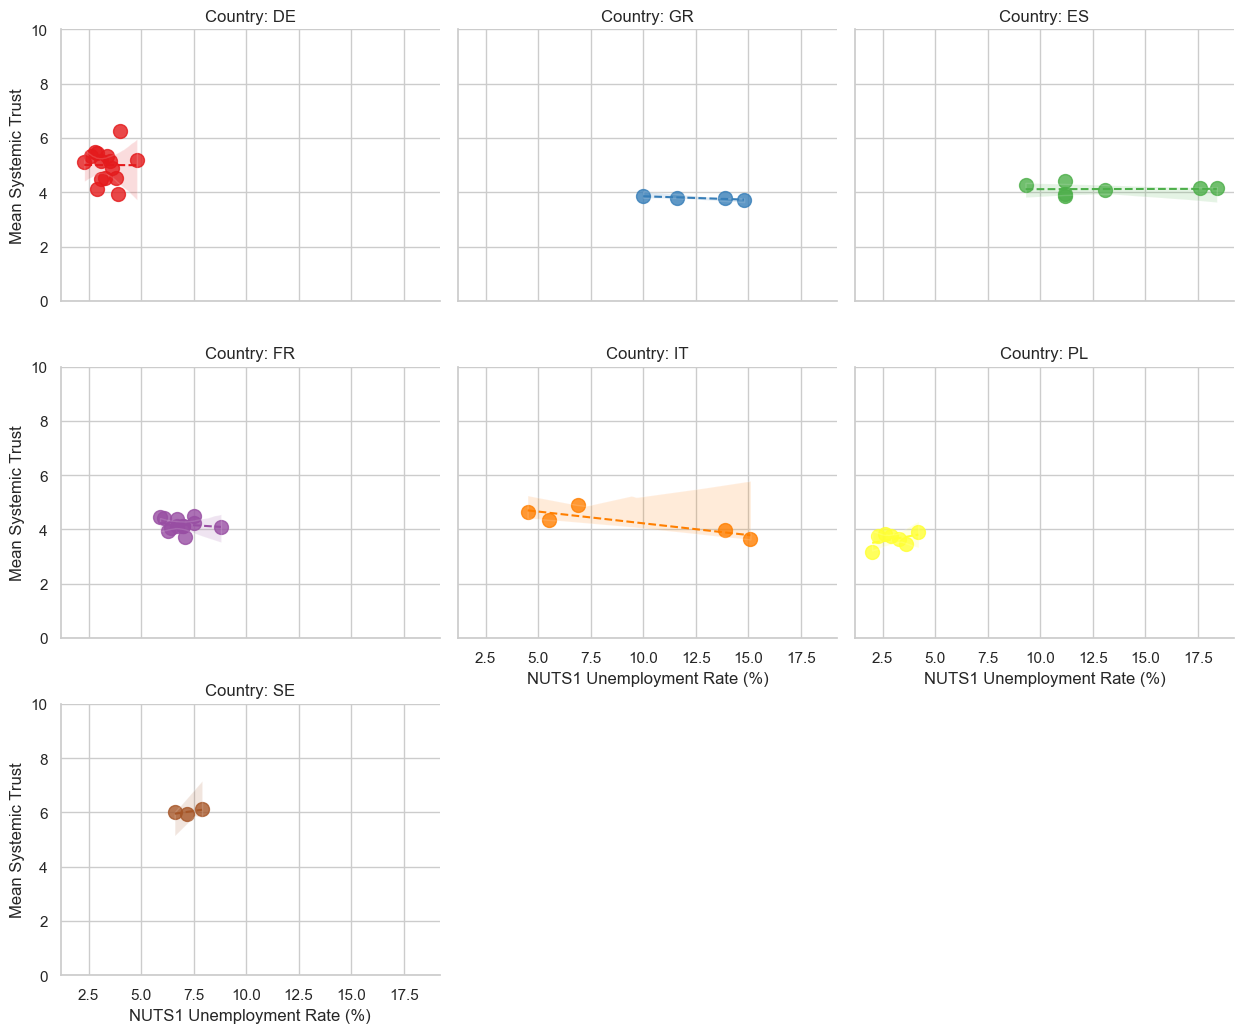

In [ ]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

# 4. Aggregate individuals up to NUTS1 regional portfolios
regional_portfolios = ess_survey.groupby(['nuts1_region', 'country_code']).agg({
    'nuts1_unemployment_rate_pct_2022': 'first',
    'trust_index': 'mean'
}).reset_index()

# 5. Use lmplot to facet by country and automatically draw trendlines
# col_wrap=3 organizes the 6 countries into a clean 2x3 grid matrix
g = sns.lmplot(
    data=regional_portfolios,
    x='nuts1_unemployment_rate_pct_2022',
    y='trust_index',
    col='country_code',
    col_wrap=3,
    hue='country_code',
    palette='Set1',
    height=3.5,
    aspect=1.2,
    scatter_kws={'s': 100, 'alpha': 0.8},
    line_kws={'linestyle': '--', 'linewidth': 1.5}
)

# 6. Polish layouts, titles, and label parameters across all subplots
g.set_axis_labels("NUTS1 Unemployment Rate (%)", "Mean Systemic Trust")
g.set_titles(col_template="Country: {col_name}")

# Enforce consistent formatting across axes limits
for ax in g.axes.flat:
    ax.set_ylim(0, 10) # Enforce strict 0-10 trust scale bounds
    # Dynamically expand X-limits slightly per plot to let points breathe, 
    # but keep them clean and readable.

plt.tight_layout()
#plt.savefig('04_regional_unemployment_vs_trust_faceted.png', dpi=300)

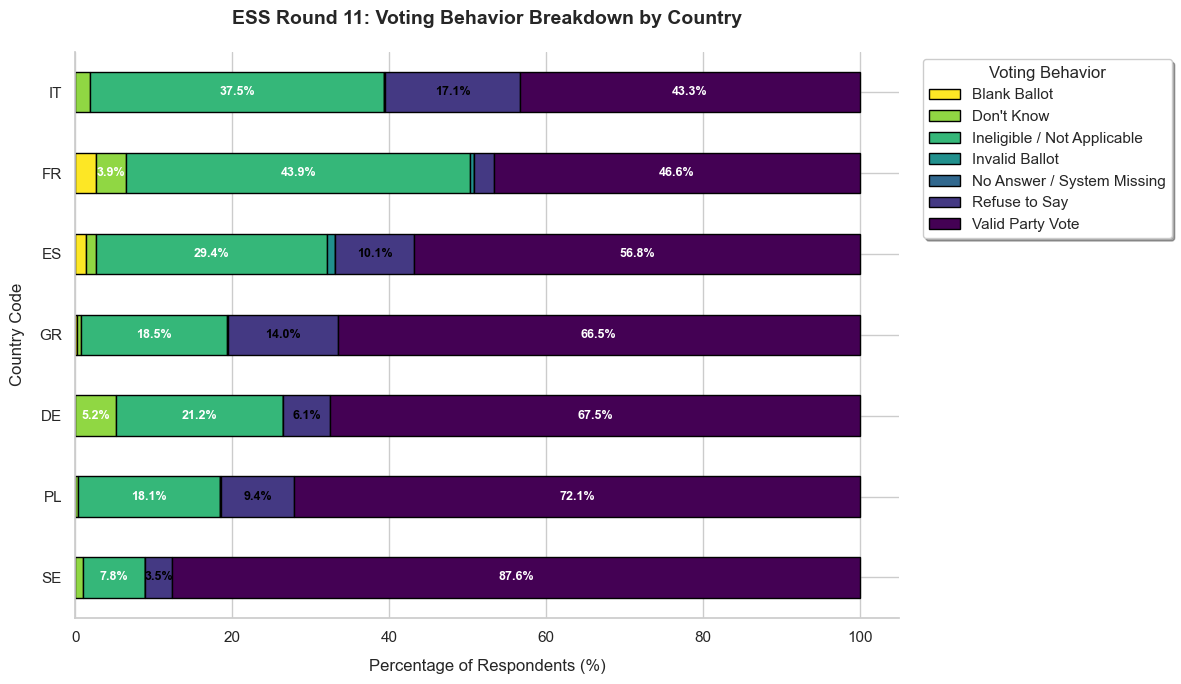

In [31]:
# 1. Calculate percentages of voting behavior by country
# This normalizes the row counts so we can see relative proportions
cross_tab = pd.crosstab(
    ess_survey["country_code"],
    ess_survey["voting_behavior_manifest"],
    normalize="index",  # Calculates percentages per row (country)
) * 100

# 2. Sort the countries by a specific category to make the visual cleaner
# Sorting by 'Valid Party Vote' gives the chart a nice visual gradient
cross_tab = cross_tab.sort_values(by="Valid Party Vote", ascending=False)

# 3. Plotting the 100% Stacked Bar Chart
ax = cross_tab.plot(
    kind="barh", stacked=True, figsize=(12, 7), cmap="viridis_r", edgecolor="black"
)

# 4. Styling and Aesthetics
sns.despine()  # Cleans up the top and right borders
plt.title(
    "ESS Round 11: Voting Behavior Breakdown by Country",
    fontsize=14,
    pad=20,
    weight="bold",
)
plt.xlabel("Percentage of Respondents (%)", fontsize=12, labelpad=10)
plt.ylabel("Country Code", fontsize=12, labelpad=10)

# Move the legend outside so it doesn't overlap the bars
plt.legend(
    title="Voting Behavior",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    shadow=True,
)

# 5. Add percentage labels directly onto the bars for scannability
# (Only adds labels for blocks larger than 3% to avoid messy overlap)
for p in ax.patches:
    width = p.get_width()
    if width > 3:  # Skip labeling tiny slices (like system slips)
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.text(
            x,
            y,
            f"{width:.1f}%",
            ha="center",
            va="center",
            color="white" if p.get_facecolor()[2] < 0.5 else "black",
            fontsize=9,
            weight="bold",
        )

plt.tight_layout()
plt.show()

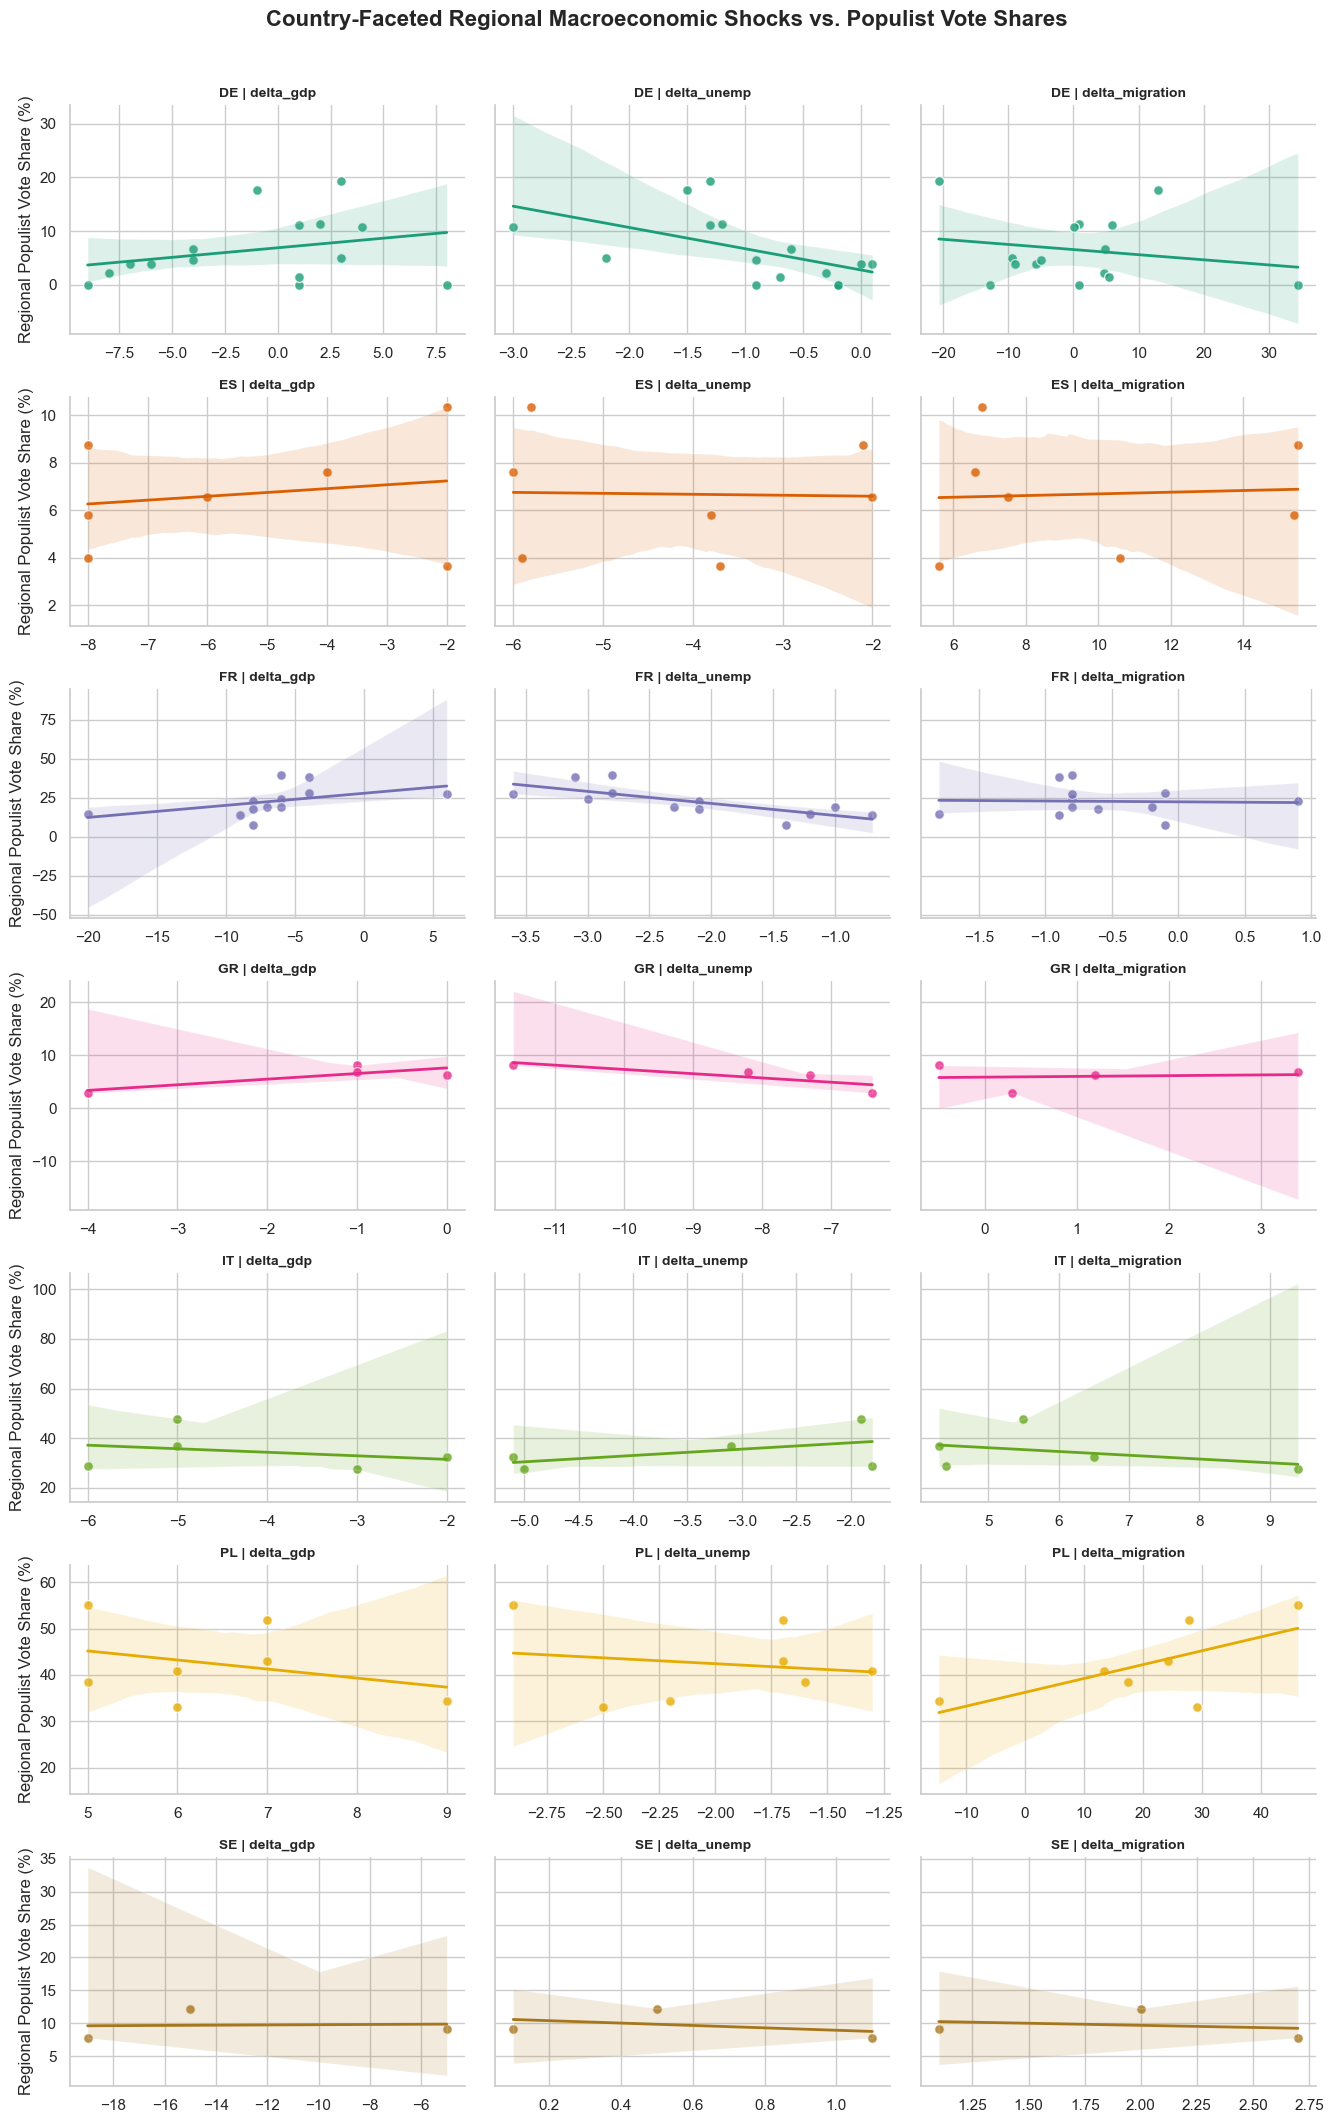

In [32]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

# 1. Drop the missing target rows FIRST to isolate active voters
df_active_voters = ess_survey.dropna(subset=['rw_populist_vote']).copy()

# 2. Group by NUTS1 to find the true regional populist vote share of the active electorate
df_regional = (
    df_active_voters.groupby(['country_code', 'nuts1_region'])
    .agg(
        # This gives the exact percentage of active voters who chose a populist party
        populist_vote_pct=('rw_populist_vote', lambda x: x.mean() * 100),
        
        # Pull your macro deltas securely
        delta_gdp=('delta_nuts1_gdp_pct_eu_avg_5yr', 'first'),
        delta_unemp=('delta_nuts1_unemployment_rate_5yr', 'first'),
        delta_migration=('delta_nuts1_net_migration_2yr', 'first')
    )
    .reset_index()
)

# 3. Melt this clean regional dataset into df_long for your FacetGrid
df_long = df_regional.melt(
    id_vars=['country_code', 'nuts1_region', 'populist_vote_pct'],
    value_vars=['delta_gdp', 'delta_unemp', 'delta_migration'],
    var_name='macro_shock_metric',
    value_name='shock_value'
)
# Render a grid where:
# - Each Row is a Country (7 rows)
# - Each Column is a Macro Shock Metric (3 columns)
g = sns.FacetGrid(
    df_long,
    row="country_code",
    col="macro_shock_metric",
    hue="country_code",  # Keeps the same country colors from your plot
    palette="Dark2",
    height=3,
    aspect=1.5,
    sharex=False,  # Essential: Metrics have different scales
    sharey="row",  # Changes y-axis scale per row so low-populist countries aren't flattened lines
)

# 1. Map the scatter points
g.map(plt.scatter, "shock_value", "populist_vote_pct", alpha=0.8, edgecolor="w", s=50)

# 2. Map distinct linear regression trendlines for EACH individual country block
g.map(
    sns.regplot,
    "shock_value",
    "populist_vote_pct",
    scatter=False,
    line_kws={"linestyle": "-", "linewidth": 2},
)

# 3. Styling & Labels
g.set_titles(template="{row_name} | {col_name}", weight="bold", size=10)
g.set_axis_labels("", "Regional Populist Vote Share (%)")

# Add a professional overall title above the subplots
plt.suptitle(
    "Country-Faceted Regional Macroeconomic Shocks vs. Populist Vote Shares",
    fontsize=16,
    weight="bold",
    y=1.01,
)

plt.tight_layout()
plt.show()

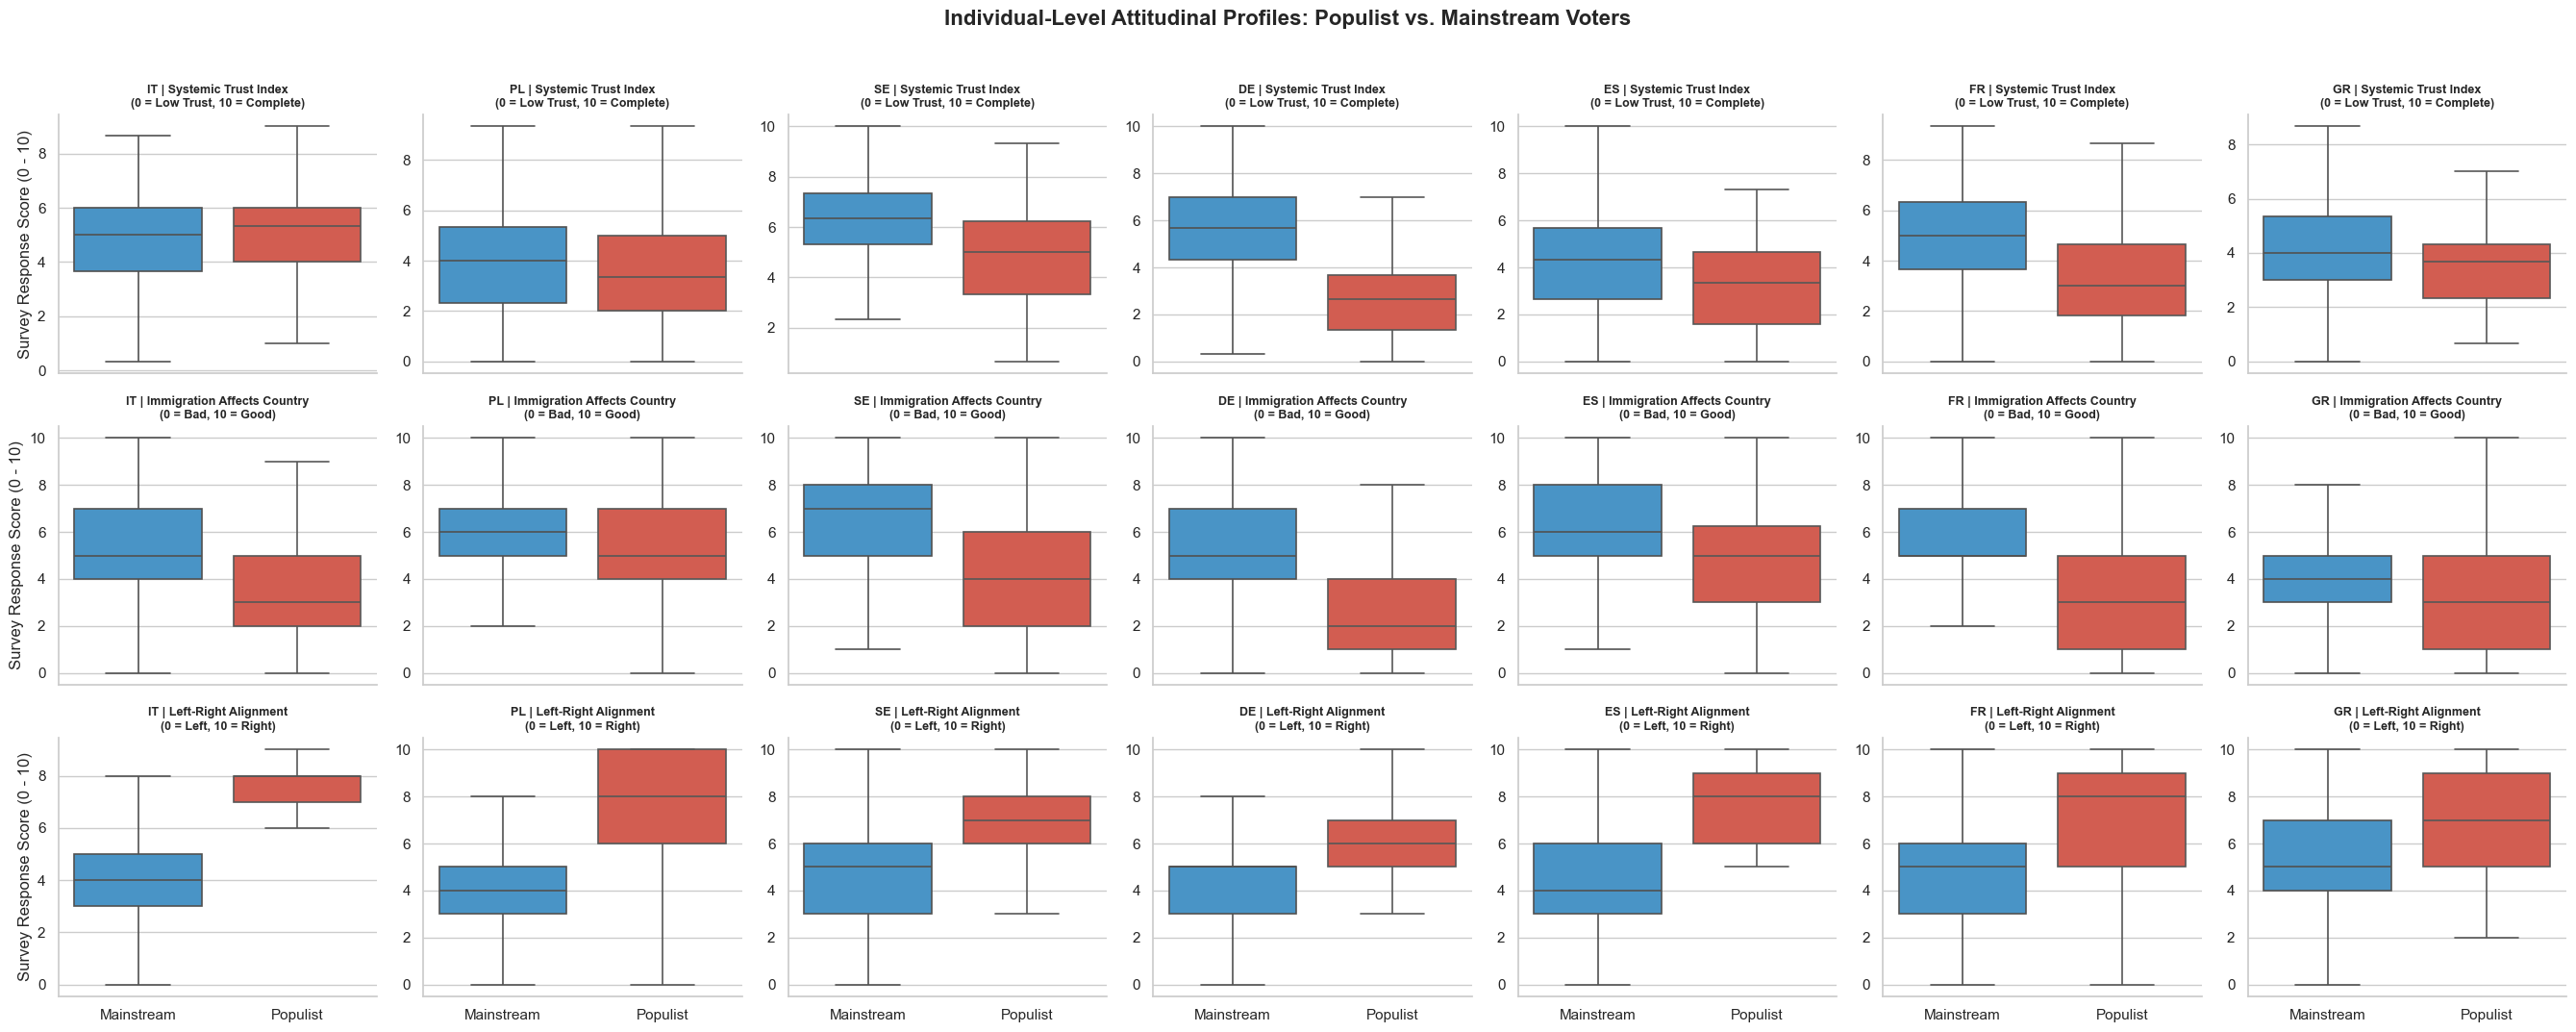

In [80]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

# 1.
attitudinal_vars = ["trust_index", "immigrants_impact_country", "left_right_alignment"]

# Filter out rows where our target or features are missing
df_clean = ess_survey.dropna(subset=["rw_populist_vote"] + attitudinal_vars).copy()

# Ensure target is treated as a clean categorical string for plotting
df_clean["Voter Type"] = df_clean["rw_populist_vote"].map(
    {1: "Populist", 0: "Mainstream"}
)

# 2. Melt data to long format
df_attitudes_long = pd.melt(
    df_clean,
    id_vars=["respondent_id", "country_code", "Voter Type"],
    value_vars=attitudinal_vars,
    var_name="Attitude_Metric",
    value_name="Score",
)

# FIXED: Match keys perfectly to attitudinal_vars
metric_labels = {
    "trust_index": "Systemic Trust Index\n(0 = Low Trust, 10 = Complete)",
    "immigrants_impact_country": "Immigration Affects Country\n(0 = Bad, 10 = Good)",
    "left_right_alignment": "Left-Right Alignment\n(0 = Left, 10 = Right)",
}
df_attitudes_long["Attitude_Metric"] = df_attitudes_long["Attitude_Metric"].map(
    metric_labels
)

# 3. Render the FacetGrid Matrix
g = sns.FacetGrid(
    df_attitudes_long,
    row="Attitude_Metric",
    col="country_code",
    hue="Voter Type",
    palette={"Mainstream": "#3498db", "Populist": "#e74c3c"},
    height=3.5,
    aspect=1.1,
    sharey=False,
)

# Map the boxplots
g.map(
    sns.boxplot,
    "Voter Type",
    "Score",
    order=["Mainstream", "Populist"],
    showfliers=False,
    linewidth=1.2,
)

# 4. Styling & Layout Polish
g.set_titles(template="{col_name} | {row_name}", weight="bold", size=9)
g.set_axis_labels("", "Survey Response Score (0 - 10)")

plt.suptitle(
    "Individual-Level Attitudinal Profiles: Populist vs. Mainstream Voters",
    fontsize=16,
    weight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

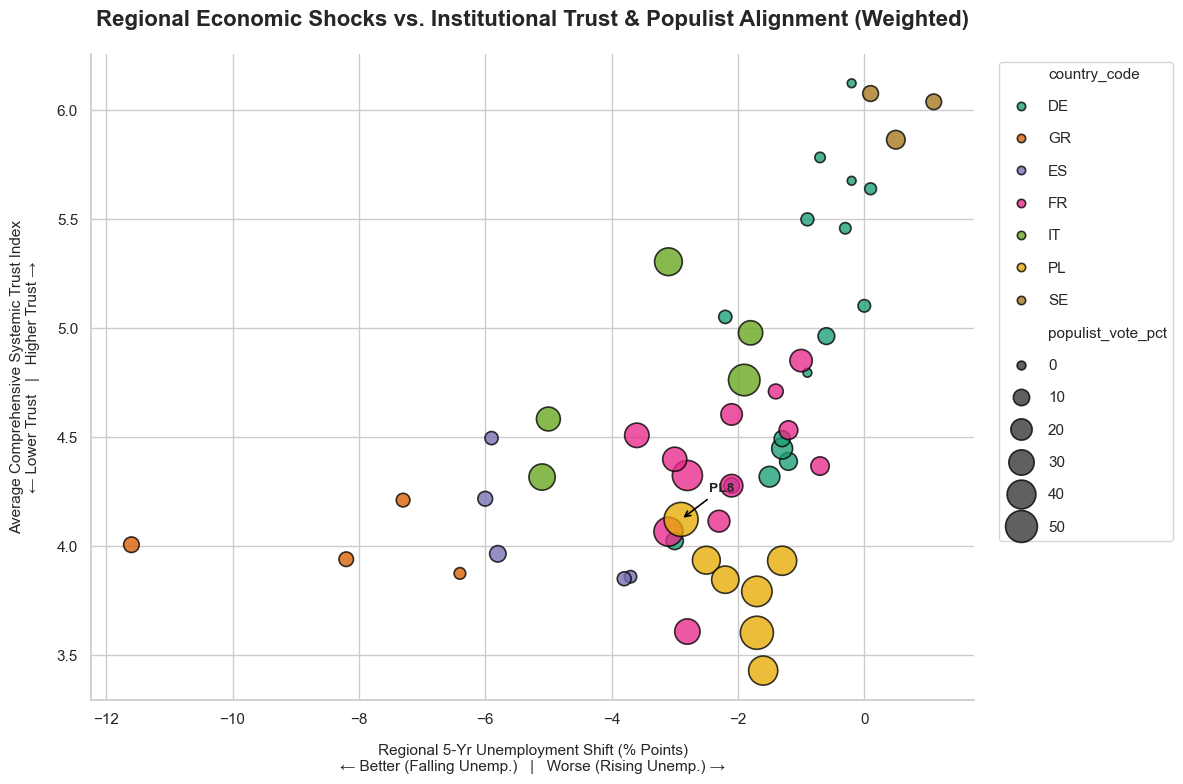

In [50]:
# Drop missing target and weight rows to isolate active, valid voter responses
df_active_voters = ess_survey.dropna(
    subset=["rw_populist_vote", "model_analysis_wt"]
).copy()


# ==========================================
# 1. WEIGHTED AGGREGATION TO NUTS 1 LEVEL
# ==========================================
# Define a helper function to calculate the true weighted mean per group
def calculate_regional_metrics(group):
    weights = group["model_analysis_wt"]

    # Calculate weighted means
    weighted_trust = np.average(group["trust_index"], weights=weights)
    weighted_populist_share = np.average(
        group["rw_populist_vote"], weights=weights
    )

    return pd.Series(
        {
            "trust_index": weighted_trust,
            "populist_vote_pct": weighted_populist_share * 100,
            # Economic shock is identical for everyone in the region; take the first
            "delta_nuts1_unemployment_rate_5yr": group[
                "delta_nuts1_unemployment_rate_5yr"
            ].iloc[0],
            "country_code": group["country_code"].iloc[0],
        }
    )


# Apply the weighted calculations across NUTS 1 regions
df_bridge = (
    df_active_voters.groupby("nuts1_region")
    .apply(calculate_regional_metrics, include_groups=False)
    .dropna()
    .reset_index()
)

# ==========================================
# 2. RENDER THE MULTILEVEL BUBBLE CHART
# ==========================================
plt.figure(figsize=(12, 8))

# Define bubble scaling boundaries based on true weighted vote share percentage
sns.scatterplot(
    data=df_bridge,
    x="delta_nuts1_unemployment_rate_5yr",
    y="trust_index",
    hue="country_code",
    size="populist_vote_pct",
    sizes=(40, 600),
    palette="Dark2",
    alpha=0.78,
    edgecolor="black",
    linewidth=1.2,
)

# ==========================================
# 3. GRAPH STYLING & INTUITION ANCHORS
# ==========================================
plt.title(
    "Regional Economic Shocks vs. Institutional Trust & Populist Alignment (Weighted)",
    fontsize=16,
    weight="bold",
    pad=20,
)
plt.xlabel(
    "Regional 5-Yr Unemployment Shift (% Points)\n← Better (Falling Unemp.)   |   Worse (Rising Unemp.) →",
    fontsize=11,
    labelpad=12,
)
plt.ylabel(
    "Average Comprehensive Systemic Trust Index\n← Lower Trust   |   Higher Trust →",
    fontsize=11,
    labelpad=12,
)

# Clean up layout and legends
sns.despine()

# Organize the legends cleanly on the right flank so they don't overlap the bubbles
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    markerscale=1,
    labelspacing=1.2,
)

# Label extreme standout region directly on the plot using the new weighted metric
highest_populist_region = df_bridge.loc[df_bridge["populist_vote_pct"].idxmax()]
plt.annotate(
    highest_populist_region["nuts1_region"],
    xy=(
        highest_populist_region["delta_nuts1_unemployment_rate_5yr"],
        highest_populist_region["trust_index"],
    ),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
    fontsize=10,
    weight="bold",
)

plt.tight_layout()
plt.show()

## Regressions
To test for potential multicollinearity across our individual and macro-regional variables, Variance Inflation Factors (VIF) were calculated across all independent variables. All core individual-level attitudinal and socioeconomic controls display highly robust independence, with VIF scores resting well below 2.0. Mild elevation was observed in the 5-year regional unemployment shock metric (VIF = 7.95) and the Greek national baseline indicator (VIF = 9.26). This covariance is a natural mathematical reflection of nested macroeconomic variations across Southern Europe. Because all features remain safely below the conservative threshold of 10.0, and our regression specifications utilize country-clustered standard errors, the model is mathematically stable and free from problematic multicollinearity.

In [ ]:

# =====================================================================
# 1. PREPARE THE DESIGN MATRIX (X)
# =====================================================================
# Select ONLY the independent variables you are feeding into your formula
vif_features = [
    "trust_index",
    "immigrants_impact_country",
    "left_right_alignment",
    "educ_attainment",
    "intergen_educational_mobility",
    "hh_income_comfort",
    "unemp_last_5_years",
    "age",
    "gender",
    "delta_nuts1_gdp_pct_eu_avg_5yr",
    "delta_nuts1_unemployment_rate_5yr",
    "delta_nuts1_net_migration_2yr",
    "country_code" # Categorical - must be encoded
]
# Drop missing rows across these specific features to align with your model universe
df_vif_prep = ess_survey[vif_features].dropna().copy()

# Convert categorical country_code into 0/1 numeric dummy columns 
# (drop_first=True mirrors exactly how statsmodels treats C(country_code) references)
X = pd.get_dummies(df_vif_prep, columns=["country_code"], drop_first=True, dtype=int)

# CRITICAL STEP: statsmodels VIF requires an explicit intercept/constant column
X = sm.add_constant(X)

# =====================================================================
# 2. CALCULATE VARIANCE INFLATION FACTORS
# =====================================================================
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Filter out the constant row so we focus entirely on our variables
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

print("═" * 60)
print("VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS")
print("═" * 60)
print(vif_data.to_string(index=False, formatters={"VIF": "{:.2f}".format}))

════════════════════════════════════════════════════════════
VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS
════════════════════════════════════════════════════════════
                          Feature  VIF
                  country_code_GR 9.26
delta_nuts1_unemployment_rate_5yr 7.95
   delta_nuts1_gdp_pct_eu_avg_5yr 3.92
                  country_code_PL 3.43
                  country_code_ES 3.12
                  country_code_IT 2.50
                  country_code_SE 2.37
                  country_code_FR 2.06
    delta_nuts1_net_migration_2yr 1.95
                  educ_attainment 1.90
    intergen_educational_mobility 1.72
                hh_income_comfort 1.39
        immigrants_impact_country 1.34
                              age 1.28
                      trust_index 1.27
             left_right_alignment 1.14
               unemp_last_5_years 1.07
                           gender 1.01


### Macro level model

In [95]:
# ==========================================
# MACRO CONTEXT MODEL (Model 1)
# Focus: Regional shocks and contextual structure
# ==========================================

macro_cols = [
    "rw_populist_vote",                        # Target variable
    "model_analysis_wt",                       # Survey weights

    # Minimal individual composition controls (optional but kept for robustness)
    "age",
    "gender",
    "educ_attainment",

    # Macro-level structural shocks (core explanatory variables)
    "delta_nuts1_gdp_pct_eu_avg_5yr",
    "delta_nuts1_unemployment_rate_5yr",
    "delta_nuts1_net_migration_2yr",

    # Structural grouping variables
    "country_code",
    "nuts1_region"
]

# Clean estimation sample
df_macro = ess_survey[macro_cols].dropna()

# ==========================================
# MODEL FORMULA (MACRO-FOCUSED)
# ==========================================

macro_formula = (
    "rw_populist_vote ~ "
    "delta_nuts1_gdp_pct_eu_avg_5yr + "
    "delta_nuts1_unemployment_rate_5yr + "
    "delta_nuts1_net_migration_2yr + "
    "C(country_code)"
)

# ==========================================
# FIT MODEL
# ==========================================

macro_logit_model = smf.glm(
    formula=macro_formula,
    data=df_macro,
    family=sm.families.Binomial(),
    var_weights=df_macro["model_analysis_wt"]
).fit()

print(macro_logit_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       rw_populist_vote   No. Observations:                 8643
Model:                            GLM   Df Residuals:                     8633
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -5918.8
Date:                Fri, 12 Jun 2026   Deviance:                       11838.
Time:                        17:29:17   Pearson chi2:                 1.37e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2013
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

### Individual level model

In [81]:
# Individual model version 1
# Isolate individual-level features 
model_cols = [
    "rw_populist_vote",  # Target (Dropped NaNs natively restrict to active voters)
    "model_analysis_wt", # Weighting variable
    "trust_index",  # Replaced individual trst_pol_parties
    "immigrants_impact_country", 
    "intergen_educational_mobility",
    "educ_attainment",
    "hh_income_comfort",
    "unemp_last_5_years",
    "gender",
    "age",
    "country_code",  # Used for baseline country fixed-effects
]


# Create a clean modeling matrix free of missing values
df_logit = ess_survey[model_cols].dropna()

# ==========================================
# 2. FIT THE FIXED-EFFECTS LOGISTIC MODEL
# ==========================================

logit_model_mobility = smf.glm(
    formula="rw_populist_vote ~ trust_index + immigrants_impact_country + educ_attainment + intergen_educational_mobility + hh_income_comfort + unemp_last_5_years + gender + age + C(country_code)",
    data=df_logit,
    family=sm.families.Binomial(),
    freq_weights=df_logit["model_analysis_wt"] # <-- CRITICAL ADDITION
).fit()
# Print the final baseline parameter diagnostics
print(logit_model_mobility.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       rw_populist_vote   No. Observations:                 8219
Model:                            GLM   Df Residuals:                 12911.50
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4776.6
Date:                Fri, 12 Jun 2026   Deviance:                       9553.1
Time:                        16:47:08   Pearson chi2:                 1.23e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3255
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

 With a heavy heart, I am deciding to drop the intergenerational mobility variable (intergenerational education deviation) from the main specification. Although it was designed to capture whether individuals are above or below the educational level of their parents, in practice it is highly correlated with education and does not materially improve model fit or change the main conclusions.

 When included, it produces a small but significant positive coefficient, but the implications are ambiguous. Given that the goal of the project is to explain voting behaviour in a way that is interpretable and accessible, especially for a non-technical audience, the added complexity of this variable outweighs its marginal explanatory benefit.

 For this reason, the main model focuses on absolute education (educ_attainment) as the more straightforward and interpretable measure of socioeconomic position, while mobility is included above for robustness checks and exploratory analysis.

In [82]:
ess_survey["intergen_educational_mobility"].isna().sum() # 679, this is meaningful and likely non-random
ess_survey["educ_attainment"].isna().sum() # 78

# Verifying relationship between educational attainment and intergenerational mobility, danger of multicollinearity
df_logit["intergen_educational_mobility"].describe()

df_logit[["educ_attainment",
          "intergen_educational_mobility"]].corr()

,educ_attainment,intergen_educational_mobility
educ_attainment,1.000000,0.458428
intergen_educational_mobility,0.458428,1.000000


In [83]:
mobility_df = ess_survey[[
    "intergen_educational_mobility",
    "educ_attainment"
]].replace([np.inf, -np.inf], np.nan).dropna()

X = sm.add_constant(mobility_df["educ_attainment"])
y = mobility_df["intergen_educational_mobility"]

mobility_model = sm.OLS(y, X).fit()

ess_survey.loc[mobility_df.index, "mobility_residual"] = mobility_model.resid

ess_survey[["educ_attainment", "mobility_residual"]].corr()

df_logit = ess_survey.dropna(subset=[
    "rw_populist_vote",
    "trust_index",
    "immigrants_impact_country",
    "educ_attainment",
    "mobility_residual",
    "hh_income_comfort",
    "unemp_last_5_years",
    "gender",
    "age",
    "country_code"
])

logit_model_orthogonal_mobility = smf.glm(
    formula="""
        rw_populist_vote ~
        trust_index +
        immigrants_impact_country +
        educ_attainment +
        mobility_residual +
        hh_income_comfort +
        unemp_last_5_years +
        gender +
        age +
        C(country_code)
    """,
    data=df_logit,
    family=sm.families.Binomial(),
    freq_weights=df_logit["model_analysis_wt"]
).fit()

print(logit_model_orthogonal_mobility.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       rw_populist_vote   No. Observations:                 8219
Model:                            GLM   Df Residuals:                 12911.50
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4776.6
Date:                Fri, 12 Jun 2026   Deviance:                       9553.1
Time:                        16:47:19   Pearson chi2:                 1.23e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3255
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [84]:
# No mobility
# Intercept is DE
# Gender: 0 is male, 1 is female
logit_model_no_mobility = smf.glm(
    formula="""
        rw_populist_vote ~
        trust_index +
        immigrants_impact_country +
        educ_attainment +
        hh_income_comfort +
        unemp_last_5_years +
        gender +
        age +
        C(country_code)
    """,
    data=df_logit,
    family=sm.families.Binomial(),
    freq_weights=df_logit["model_analysis_wt"]
).fit()

print(logit_model_no_mobility.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       rw_populist_vote   No. Observations:                 8219
Model:                            GLM   Df Residuals:                 12912.50
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4804.6
Date:                Fri, 12 Jun 2026   Deviance:                       9609.2
Time:                        16:47:22   Pearson chi2:                 1.22e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3209
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

## K-Means Clustering of Region Types

In [102]:
# =====================================================================
# 1. DATA PREPARATION & WEIGHTED REGIONAL AGGREGATION
# =====================================================================
df_clean = ess_survey.dropna(subset=["model_analysis_wt", "nuts1_region"]).copy()

# Re-verify composite trust index
df_clean["trust_index"] = df_clean[
    ["trstprl", "trstlgl", "trst_pol_parties"]
].mean(axis=1)

def weighted_mean(group, value_col):
    values = group[value_col]
    weights = group["model_analysis_wt"]
    valid_mask = values.notna()
    if not valid_mask.any():
        return np.nan
    return np.average(values[valid_mask], weights=weights[valid_mask])

print("Aggregating regions to NUTS-1 level based on updated feature set...")
regional_data = []
for name, group in df_clean.groupby("nuts1_region"):
    sample_size = len(group)
    if sample_size < 100:  # Drop low-sample noise
        continue
        
    regional_data.append({
        "nuts1_region": name,
        "country_code": group["country_code"].iloc[0],
        "sample_size": sample_size,
        
        # --- Structural Pillars for Typology ---
        "nuts1_gdp_pct_eu_avg_2022": group["nuts1_gdp_pct_eu_avg_2022"].iloc[0],
        "nuts1_unemployment_rate_pct_2022": group["nuts1_unemployment_rate_pct_2022"].iloc[0],
        "trust_index": weighted_mean(group, "trust_index"),
        "educ_attainment": weighted_mean(group, "educ_attainment"),
        
        # --- Extra Model Alignments (Captured for Profiling/Dashboard use) ---
        "immigrants_impact_country": weighted_mean(group, "immigrants_impact_country"),
        "hh_income_comfort": weighted_mean(group, "hh_income_comfort"),
        "unemp_last_5_years": weighted_mean(group, "unemp_last_5_years"),
        "rw_populist_vote_share": weighted_mean(group, "rw_populist_vote") * 100
    })

df_cluster_prep = pd.DataFrame(regional_data).dropna()

# =====================================================================
# 2. STANDARDIZATION & CLUSTERING
# =====================================================================
# Cluster ONLY on the core structural baseline pillars
cluster_features = [
    "nuts1_gdp_pct_eu_avg_2022",
    "nuts1_unemployment_rate_pct_2022",
    "trust_index",
    "educ_attainment"
]

X = df_cluster_prep[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Execute K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster_prep["typology_cluster"] = kmeans.fit_predict(X_scaled)

# =====================================================================
# 3. PRINT PRESENTATION PROFILE TABLE
# =====================================================================
print("\n" + "═" * 80)
print("UPDATED REGIONAL TYPOLOGY PROFILES (INCLUDING PRECARITY METRICS)")
print("═" * 80)

# Profile across the clustering pillars AND check how voting naturally mapped to them
profile_vars = cluster_features + ["hh_income_comfort", "unemp_last_5_years", "rw_populist_vote_share", "sample_size"]
cluster_profiles = df_cluster_prep.groupby("typology_cluster")[profile_vars].mean().reset_index()

print(cluster_profiles.to_string(index=False, formatters={
    "nuts1_gdp_pct_eu_avg_2022": "{:.1f}%".format,
    "nuts1_unemployment_rate_pct_2022": "{:.2f}%".format,
    "trust_index": "{:.2f}".format,
    "educ_attainment": "{:.2f}".format,
    "hh_income_comfort": "{:.2f}".format,
    "unemp_last_5_years": "{:.2f}".format,
    "rw_populist_vote_share": "{:.1f}%".format,
    "sample_size": "{:.0f}".format
}))

Aggregating regions to NUTS-1 level based on updated feature set...

════════════════════════════════════════════════════════════════════════════════
UPDATED REGIONAL TYPOLOGY PROFILES (INCLUDING PRECARITY METRICS)
════════════════════════════════════════════════════════════════════════════════
 typology_cluster nuts1_gdp_pct_eu_avg_2022 nuts1_unemployment_rate_pct_2022 trust_index educ_attainment hh_income_comfort unemp_last_5_years rw_populist_vote_share sample_size
                0                    138.5%                            4.53%        5.33            4.04              1.59               4.84                   6.7%         311
                1                     48.3%                            2.99%        3.63            4.06              1.96               4.92                  44.5%         206
                2                     57.6%                           14.00%        3.88            3.32              2.15               4.68                  12.1%         

In [ ]:


# =========================================================
# 1. REGIONAL AGGREGATION (STRUCTURAL ONLY)
# =========================================================

df_clean = ess_survey.dropna(subset=["model_analysis_wt", "nuts1_region"]).copy()

def weighted_mean(group, col):
    x = group[col]
    w = group["model_analysis_wt"]
    mask = x.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(x[mask], weights=w[mask])

regional_data = []

for name, group in df_clean.groupby("nuts1_region"):
    
    if len(group) < 100:
        continue
    
    regional_data.append({
        "nuts1_region": name,
        "country_code": group["country_code"].iloc[0],
        "sample_size": len(group),

        # ============================
        # STRUCTURAL MACRO VARIABLES
        # ============================
        "gdp_level": group["nuts1_gdp_pct_eu_avg_2022"].iloc[0],
        "unemployment_level": group["nuts1_unemployment_rate_pct_2022"].iloc[0],
        "migration_level": group["nuts1_net_migration_2022"].iloc[0],

        # ============================
        # CONTEXTUAL OUTCOME (NOT USED FOR CLUSTERING)
        # ============================
        "populist_vote_share": weighted_mean(group, "rw_populist_vote") * 100
    })

df_regions = pd.DataFrame(regional_data).dropna()

In [ ]:
cluster_features = [
    "gdp_level",
    "unemployment_level",
    "migration_level"
]

X = df_regions[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sil_scores = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append((k, score))

print("Silhouette scores:")
for k, s in sil_scores:
    print(f"k={k}: {s:.3f}")

k_final = 4  # adjust based on silhouette results

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
df_regions["cluster"] = kmeans.fit_predict(X_scaled)

Silhouette scores:
k=2: 0.352
k=3: 0.363
k=4: 0.441
k=5: 0.468
k=6: 0.377


In [103]:
profile_vars = [
    "gdp_level",
    "unemployment_level",
    "migration_level",
    "populist_vote_share",
    "sample_size"
]

cluster_profiles = df_regions.groupby("cluster")[profile_vars].mean().reset_index()

print(cluster_profiles)

   cluster   gdp_level  unemployment_level  migration_level  \
0        0  119.714286            5.238095         4.247619   
1        1   48.285714            2.985714         0.185714   
2        2   59.857143           12.585714         0.857143   
3        3   82.166667           12.400000        13.983333   

   populist_vote_share  sample_size  
0            14.675761   306.380952  
1            44.471492   206.000000  
2            17.731098   553.714286  
3             7.063889   294.333333  


In [104]:
# Merge cluster assignment back to individuals
df_with_clusters = df_clean.merge(
    df_regions[["nuts1_region", "cluster"]],
    on="nuts1_region",
    how="left"
)

overlay = df_with_clusters.groupby("cluster").agg({
    "trust_index": "mean",
    "educ_attainment": "mean",
    "hh_income_comfort": "mean",
    "immigrants_impact_country": "mean"
}).reset_index()

print(overlay)

   cluster  trust_index  educ_attainment  hh_income_comfort  \
0      0.0     4.993844         4.171049           1.636593   
1      1.0     3.636967         4.156685           1.949650   
2      2.0     3.820672         3.751426           2.361214   
3      3.0     4.103256         3.600907           1.787706   

   immigrants_impact_country  
0                   5.257310  
1                   5.489630  
2                   4.202582  
3                   5.946913  
